In [83]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import truncnorm

Parameters:
1. Number Of Agents
2. Number of levels? Departments? Company Structure
3. Base Game Payoffs
4. Base Productivity
5. Initial Conditions: Integrity, Trust


In [88]:
class Agent: 
    def __init__(self, id, role, integrity, trust):
        self.id = id
        self.role = role
        self.integrity = integrity
        self.trust = trust
        self.utility = 0.0
        self.strategy = 1
        self.history = []
        self.perceptions = {}
        self.bosses = []
        self.peers = []
        self.underlings = []



Option 1: generate agents with network
Option 2: generate network then add agents
Option 3: generate agents then generate network

In [89]:
def generate_network(level_size):
    G = nx.DiGraph()
    ceo = Agent(0, 'CEO', truncnorm.rvs(-1, 1, loc=0, scale=1), truncnorm.rvs(-1, 1, loc=0, scale=1))
    G.add_node(ceo.id, level=0, role=ceo.role, agent=ceo)
    levels, all_agents, next_id = [], [ceo], 1
    for i, n in enumerate(level_size, start=1):
        role = 'DepartmentHead' if i == 1 else f'Level{i}'
        lvl = [Agent(next_id + j, role, truncnorm.rvs(-1, 1, loc=0, scale=1), truncnorm.rvs(-1, 1, loc=0, scale=1)) for j in range(n)]
        next_id += n
        for a in lvl: G.add_node(a.id, level=i, role=a.role, agent=a)
        levels.append(lvl); all_agents.extend(lvl)
    parents = [ceo]
    for lvl in levels:
        for j, child in enumerate(lvl):
            boss = parents[j % len(parents)]
            child.bosses.append(boss); boss.underlings.append(child); G.add_edge(boss.id, child.id)
        for i, a in enumerate(lvl):
            for b in lvl[i+1:]:
                a.peers.append(b); b.peers.append(a)
                G.add_edge(a.id, b.id); G.add_edge(b.id, a.id)
        parents = lvl
    G.graph['agents'], G.graph['levels'] = all_agents, [[ceo], *levels]
    return G

In [90]:
def plot_network(G):
    pos = nx.kamada_kawai_layout(G)
    levels = np.array([G.nodes[n]['level'] for n in G.nodes])
    integrities = np.array([G.nodes[n]['agent'].integrity for n in G.nodes])
    sizes = 1800 / (levels + 1)
    plt.figure(figsize=(10, 7))
    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)
    nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.colorbar(nodes, label='Integrity')
    plt.axis('off')
    plt.show()

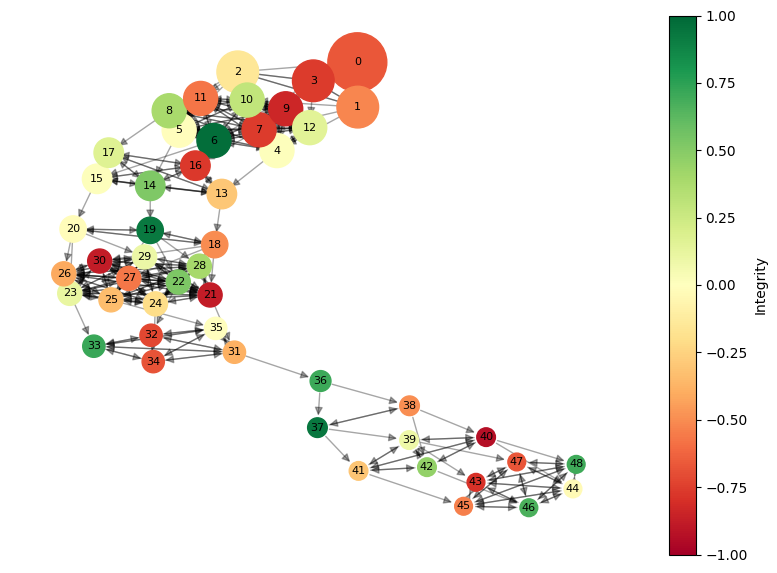

In [92]:
G = generate_network([3, 9, 5, 3, 10, 5, 1, 2, 4, 6])
plot_network(G)


agents ascribe strategy to all underlying based on perceptions
--> ascribe strategy to peers based on perceptions
--> ascribe strategy to superiors based on perceptions
Strategy expected payoffs are based on integrity, trust, and perceptions of others' strategies
cooperate cooperate results outcome: highest productivity for company
pay of boss is based on productivity of underlings 

agents update trust based on: person they can see (connected too) with highest utility: if that person is cooperating, they increase trust, if that person is defecting, they decrease trust.

agents update integrity on longer time scale (add later)

perception of others' strategies based on: trust (and history of interactions with them (add later))